In [2]:
from datasets import load_dataset
import pandas as pd

ds = load_dataset("fancyzhx/ag_news")

train_df = pd.DataFrame(ds["train"])
test_df = pd.DataFrame(ds["test"])

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print(train_df.head())

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

c:\Users\Graduate\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Graduate\.cache\huggingface\hub\datasets--fancyzhx--ag_news. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.6MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.23MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Train shape: (120000, 2)
Test shape: (7600, 2)
                                                text  label
0  Wall St. Bears Claw Back Into the Black (Reute...      2
1  Carlyle Looks Toward Commercial Aerospace (Reu...      2
2  Oil and Economy Cloud Stocks' Outlook (Reuters...      2
3  Iraq Halts Oil Exports from Main Southern Pipe...      2
4  Oil prices soar to all-time record, posing new...      2


In [5]:
# Subsample
train_df = train_df.sample(n=8000, random_state=42).reset_index(drop=True)
test_df = test_df.sample(n=2000, random_state=42).reset_index(drop=True)

print("Subsampled train shape:", train_df.shape)
print("Subsampled test shape:", test_df.shape)
print(train_df["label"].value_counts())

Subsampled train shape: (8000, 2)
Subsampled test shape: (2000, 2)
label
1    2074
3    2021
2    1959
0    1946
Name: count, dtype: int64


In [7]:
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization

# Config
MAX_TOKENS = 10000      
MAX_LEN = 50             

# Build the vectorizer
vectorize_layer = TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=MAX_LEN
)

# Learn the vocabulary from the training text
vectorize_layer.adapt(train_df["text"].values)

print("Vocabulary size:", len(vectorize_layer.get_vocabulary()))
print("Example vectorized text:")
print(train_df["text"].iloc[0])
print(vectorize_layer(train_df["text"].iloc[0:1]))

Vocabulary size: 10000
Example vectorized text:
Briefly: Legal expert joins open-source screening firm roundup Plus: Cray signs two supercomputing customers...MSN Messenger beta leaks onto Web...Level 3 to buy Sprint's dial-up business...Cisco CEO's salary shoots up from \$1...SanDisk ups capacity on flash memory cards.
tf.Tensor(
[[1650 1026 3830 2443  953    1  326 1984 1498 6566  888   41 4733    1
  5449 2620    1 2425    1  388    3  317    1    1    1    1 4779 7020
    36   23    1 2285 1947    8 2347 1152  960    0    0    0    0    0
     0    0    0    0    0    0    0    0]], shape=(1, 50), dtype=int64)


In [13]:
from tensorflow.keras import layers, models

EMBED_DIM = 64
LSTM_UNITS = 64
NUM_CLASSES = 4

model = models.Sequential([
    layers.Input(shape=(), dtype=tf.string),
    vectorize_layer,
    layers.Embedding(input_dim=MAX_TOKENS, output_dim=EMBED_DIM),
    layers.LSTM(LSTM_UNITS, dropout=0.3, recurrent_dropout=0.2),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (None, 50)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 50, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,236 (2.58 MB)

 Trainable params: 675,236 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
from sklearn.model_selection import train_test_split

texts = train_df["text"].astype(str).tolist()
labels = train_df["label"].tolist()

train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.1, random_state=42
)

train_ds = tf.data.Dataset.from_tensor_slices((train_texts, train_labels)).batch(32)
val_ds = tf.data.Dataset.from_tensor_slices((val_texts, val_labels)).batch(32)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.3592 - loss: 1.2662 - val_accuracy: 0.4925 - val_loss: 0.9533
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.5740 - loss: 0.8870 - val_accuracy: 0.6338 - val_loss: 0.9242
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.6704 - loss: 0.7002 - val_accuracy: 0.6575 - val_loss: 0.8273
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - accuracy: 0.7032 - loss: 0.6182 - val_accuracy: 0.6687 - val_loss: 0.8017
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - accuracy: 0.7126 - loss: 0.5633 - val_accuracy: 0.6800 - val_loss: 0.6811
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - accuracy: 0.7190 - loss: 0.5232 - val_accuracy: 0.7200 - val_loss: 0.6229
Epoch 7/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - accuracy: 0.7300 - loss: 0.4879 - val_accuracy: 0.6787 - val_loss: 0.7586
Epoch 8/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - accuracy: 0.7282 - loss: 0.4733 - val

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

test_texts = test_df["text"].astype(str).tolist()
test_labels = test_df["label"].tolist()

test_ds = tf.data.Dataset.from_tensor_slices((test_texts, test_labels)).batch(32)

# Get predictions
pred_probs = model.predict(test_ds)
pred_labels = pred_probs.argmax(axis=1)

# Overall metrics
acc = accuracy_score(test_labels, pred_labels)
prec = precision_score(test_labels, pred_labels, average="weighted")
rec = recall_score(test_labels, pred_labels, average="weighted")
f1 = f1_score(test_labels, pred_labels, average="weighted")

print(f"Test Accuracy: {acc:.4f}")
print(f"Test Precision (weighted): {prec:.4f}")
print(f"Test Recall (weighted): {rec:.4f}")
print(f"Test F1 (weighted): {f1:.4f}")

print("\nPer-class breakdown:")
class_names = ["World", "Sports", "Business", "Sci/Tech"]
print(classification_report(test_labels, pred_labels, target_names=class_names))

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Test Accuracy: 0.6610
Test Precision (weighted): 0.6741
Test Recall (weighted): 0.6610
Test F1 (weighted): 0.6339

Per-class breakdown:
              precision    recall  f1-score   support

       World       0.94      0.76      0.84       493
      Sports       0.85      0.95      0.90       504
    Business       0.45      0.80      0.58       474
    Sci/Tech       0.46      0.16      0.24       529

    accuracy                           0.66      2000
   macro avg       0.67      0.67      0.64      2000
weighted avg       0.67      0.66      0.63      2000



In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import time

start = time.time()

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(texts)  # reuse the same texts list from before
X_test_tfidf = tfidf.transform(test_texts)

baseline_model = LogisticRegression(max_iter=1000, n_jobs=-1)
baseline_model.fit(X_train_tfidf, labels)
baseline_pred = baseline_model.predict(X_test_tfidf)

baseline_time = time.time() - start

baseline_acc = accuracy_score(test_labels, baseline_pred)
baseline_prec = precision_score(test_labels, baseline_pred, average="weighted")
baseline_rec = recall_score(test_labels, baseline_pred, average="weighted")
baseline_f1 = f1_score(test_labels, baseline_pred, average="weighted")

print(f"Baseline (TF-IDF + Logistic Regression) — trained in {baseline_time:.1f}s")
print(f"Accuracy: {baseline_acc:.4f}")
print(f"Precision (weighted): {baseline_prec:.4f}")
print(f"Recall (weighted): {baseline_rec:.4f}")
print(f"F1 (weighted): {baseline_f1:.4f}")

c:\Users\Graduate\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Baseline (TF-IDF + Logistic Regression) — trained in 1.5s
Accuracy: 0.8725
Precision (weighted): 0.8720
Recall (weighted): 0.8725
F1 (weighted): 0.8719


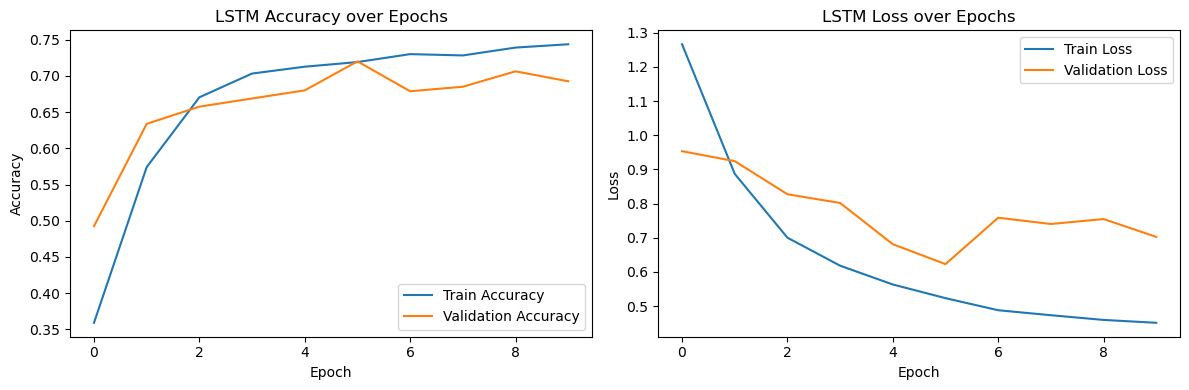

In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"], label="Train Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Validation Accuracy")
axes[0].set_title("LSTM Accuracy over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Validation Loss")
axes[1].set_title("LSTM Loss over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.savefig("../docs/lstm_training_curves.png", dpi=150)
plt.show()

Preparing Text Corpus for Language Modeling

In [21]:
# Prepare text for next-word prediction (language modeling)
# Combine text samples into one corpus
corpus = " ".join(train_df["text"].astype(str).tolist())

print("Corpus length (characters):", len(corpus))
print("Sample:", corpus[:300])

Corpus length (characters): 1897421
Sample: Briefly: Legal expert joins open-source screening firm roundup Plus: Cray signs two supercomputing customers...MSN Messenger beta leaks onto Web...Level 3 to buy Sprint's dial-up business...Cisco CEO's salary shoots up from \$1...SanDisk ups capacity on flash memory cards. New Parks Offer Lessons Se


In [22]:
import numpy as np

# Tokenize into words
words = corpus.split()
print("Total words:", len(words))

# Build vocabulary
vocab_size = 8000
word_counts = {}
for w in words:
    word_counts[w] = word_counts.get(w, 0) + 1

# Keep the most common words
sorted_words = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)
vocab = ["<UNK>"] + [w for w, _ in sorted_words[:vocab_size - 1]]

word_to_idx = {w: i for i, w in enumerate(vocab)}
idx_to_word = {i: w for i, w in enumerate(vocab)}

print("Vocabulary size:", len(vocab))
print("Top 10 words:", vocab[1:11])

Total words: 302645
Vocabulary size: 8000
Top 10 words: ['the', 'to', 'a', 'of', 'in', 'and', 'on', 'for', '-', '#39;s']


In [23]:
# Convert corpus to sequence of word indices
word_indices = [word_to_idx.get(w, 0) for w in words]  # 0 = <UNK>

# Build input/target pairs: given SEQ_LEN words, predict the next word
SEQ_LEN = 10

X = []
y = []
for i in range(len(word_indices) - SEQ_LEN):
    X.append(word_indices[i:i + SEQ_LEN])
    y.append(word_indices[i + SEQ_LEN])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Example input (word indices):", X[0])
print("Example input (words):", [idx_to_word[i] for i in X[0]])
print("Example target (word):", idx_to_word[y[0]])

X shape: (302635, 10)
y shape: (302635,)
Example input (word indices): [2925 4500 4501 3418 1093    0  372 2721 2926 6482]
Example input (words): ['Briefly:', 'Legal', 'expert', 'joins', 'open-source', '<UNK>', 'firm', 'roundup', 'Plus:', 'Cray']
Example target (word): signs


In [25]:
# Subsample
np.random.seed(42)
sample_size = 30000
idx = np.random.choice(len(X), size=sample_size, replace=False)

X_sample = X[idx]
y_sample = y[idx]

print("Sampled X shape:", X_sample.shape)
print("Sampled y shape:", y_sample.shape)

Sampled X shape: (30000, 10)
Sampled y shape: (30000,)


Building the Language Model (Next-Word Prediction)

In [26]:
lm_model = models.Sequential([
    layers.Input(shape=(SEQ_LEN,)),
    layers.Embedding(input_dim=vocab_size, output_dim=64),
    layers.LSTM(128, dropout=0.3, recurrent_dropout=0.2),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(vocab_size, activation="softmax")
])

lm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

lm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 10, 64)         │       512,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8000)           │     1,032,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,659,328 (6.33 MB)

 Trainable params: 1,659,328 (6.33 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
lm_history = lm_model.fit(
    X_sample, y_sample,
    validation_split=0.1,
    epochs=15,
    batch_size=64
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.1653 - loss: 6.8796 - val_accuracy: 0.1593 - val_loss: 6.6423
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.1661 - loss: 6.4393 - val_accuracy: 0.1593 - val_loss: 6.7075
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.1661 - loss: 6.3369 - val_accuracy: 0.1593 - val_loss: 6.7606
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.1662 - loss: 6.2493 - val_accuracy: 0.1593 - val_loss: 6.8384
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.1659 - loss: 6.1443 - val_accuracy: 0.1613 - val_loss: 6.9165
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.1741 - loss: 6.0035 - val_accuracy: 0.1673 - val_loss: 7.0109
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.1800 - loss: 5.8628 - val_accuracy: 0.1623 - val_loss: 7.1133
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.1831 - loss: 5.7299 - val_accu

In [28]:
# Retry with more data and stronger regularization
np.random.seed(42)
sample_size_v2 = 80000
idx_v2 = np.random.choice(len(X), size=sample_size_v2, replace=False)

X_sample_v2 = X[idx_v2]
y_sample_v2 = y[idx_v2]

print("New sample size:", X_sample_v2.shape)

lm_model_v2 = models.Sequential([
    layers.Input(shape=(SEQ_LEN,)),
    layers.Embedding(input_dim=vocab_size, output_dim=64),
    layers.LSTM(64, dropout=0.5, recurrent_dropout=0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(vocab_size, activation="softmax")
])

lm_model_v2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

lm_history_v2 = lm_model_v2.fit(
    X_sample_v2, y_sample_v2,
    validation_split=0.1,
    epochs=20,
    batch_size=64,
    callbacks=[early_stop]
)

New sample size: (80000, 10)
Epoch 1/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.1658 - loss: 6.7941 - val_accuracy: 0.1641 - val_loss: 6.6385
Epoch 2/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.1664 - loss: 6.5438 - val_accuracy: 0.1641 - val_loss: 6.6206
Epoch 3/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.1686 - loss: 6.4425 - val_accuracy: 0.1731 - val_loss: 6.5626
Epoch 4/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.1732 - loss: 6.3380 - val_accuracy: 0.1769 - val_loss: 6.5406
Epoch 5/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.1771 - loss: 6.2501 - val_accuracy: 0.1781 - val_loss: 6.5283
Epoch 6/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.1793 - loss: 6.1614 - val_accuracy: 0.1785 - val_loss: 6.5151
Epoch 7/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.1838 - loss: 6.0783 - val_accuracy: 0.1854 - val_loss: 6.5083
Epoch 8/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 12s 11

In [29]:
import math

# Perplexity = exp(loss), a standard language model metric
final_val_loss = min(lm_history_v2.history["val_loss"])
perplexity = math.exp(final_val_loss)

print(f"Best validation loss: {final_val_loss:.4f}")
print(f"Perplexity: {perplexity:.2f}")

Best validation loss: 6.4987
Perplexity: 664.28


In [30]:
def generate_text(model, seed_text, num_words=20, temperature=1.0):
    words_generated = seed_text.split()
    
    for _ in range(num_words):
        # Convert current words to indices, pad/truncate to SEQ_LEN
        input_indices = [word_to_idx.get(w, 0) for w in words_generated[-SEQ_LEN:]]
        while len(input_indices) < SEQ_LEN:
            input_indices = [0] + input_indices
        input_arr = np.array([input_indices])
        
        # Predict next word probabilities
        pred_probs = model.predict(input_arr, verbose=0)[0]
        
        # Apply temperature for sampling diversity
        pred_probs = np.log(pred_probs + 1e-8) / temperature
        pred_probs = np.exp(pred_probs) / np.sum(np.exp(pred_probs))
        
        next_idx = np.random.choice(len(pred_probs), p=pred_probs)
        next_word = idx_to_word[next_idx]
        words_generated.append(next_word)
    
    return " ".join(words_generated)

# Try generating text from a few seed phrases
for seed in ["The stock market", "Scientists announced", "The football team"]:
    generated = generate_text(lm_model_v2, seed, num_words=15)
    print(f"Seed: '{seed}'")
    print(f"Generated: {generated}\n")

Seed: 'The stock market'
Generated: The stock market out in a Wednesday and <UNK> stated to business settlement more is spam <UNK> complete

Seed: 'Scientists announced'
Generated: Scientists announced stores named <UNK> at the site in an its season-high afternoon the base and that

Seed: 'The football team'
Generated: The football team as <UNK> by IBM &lt;A <UNK> <UNK> <UNK> <UNK> growth attack he child and giant

